<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Collective_excitation_visualizations_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

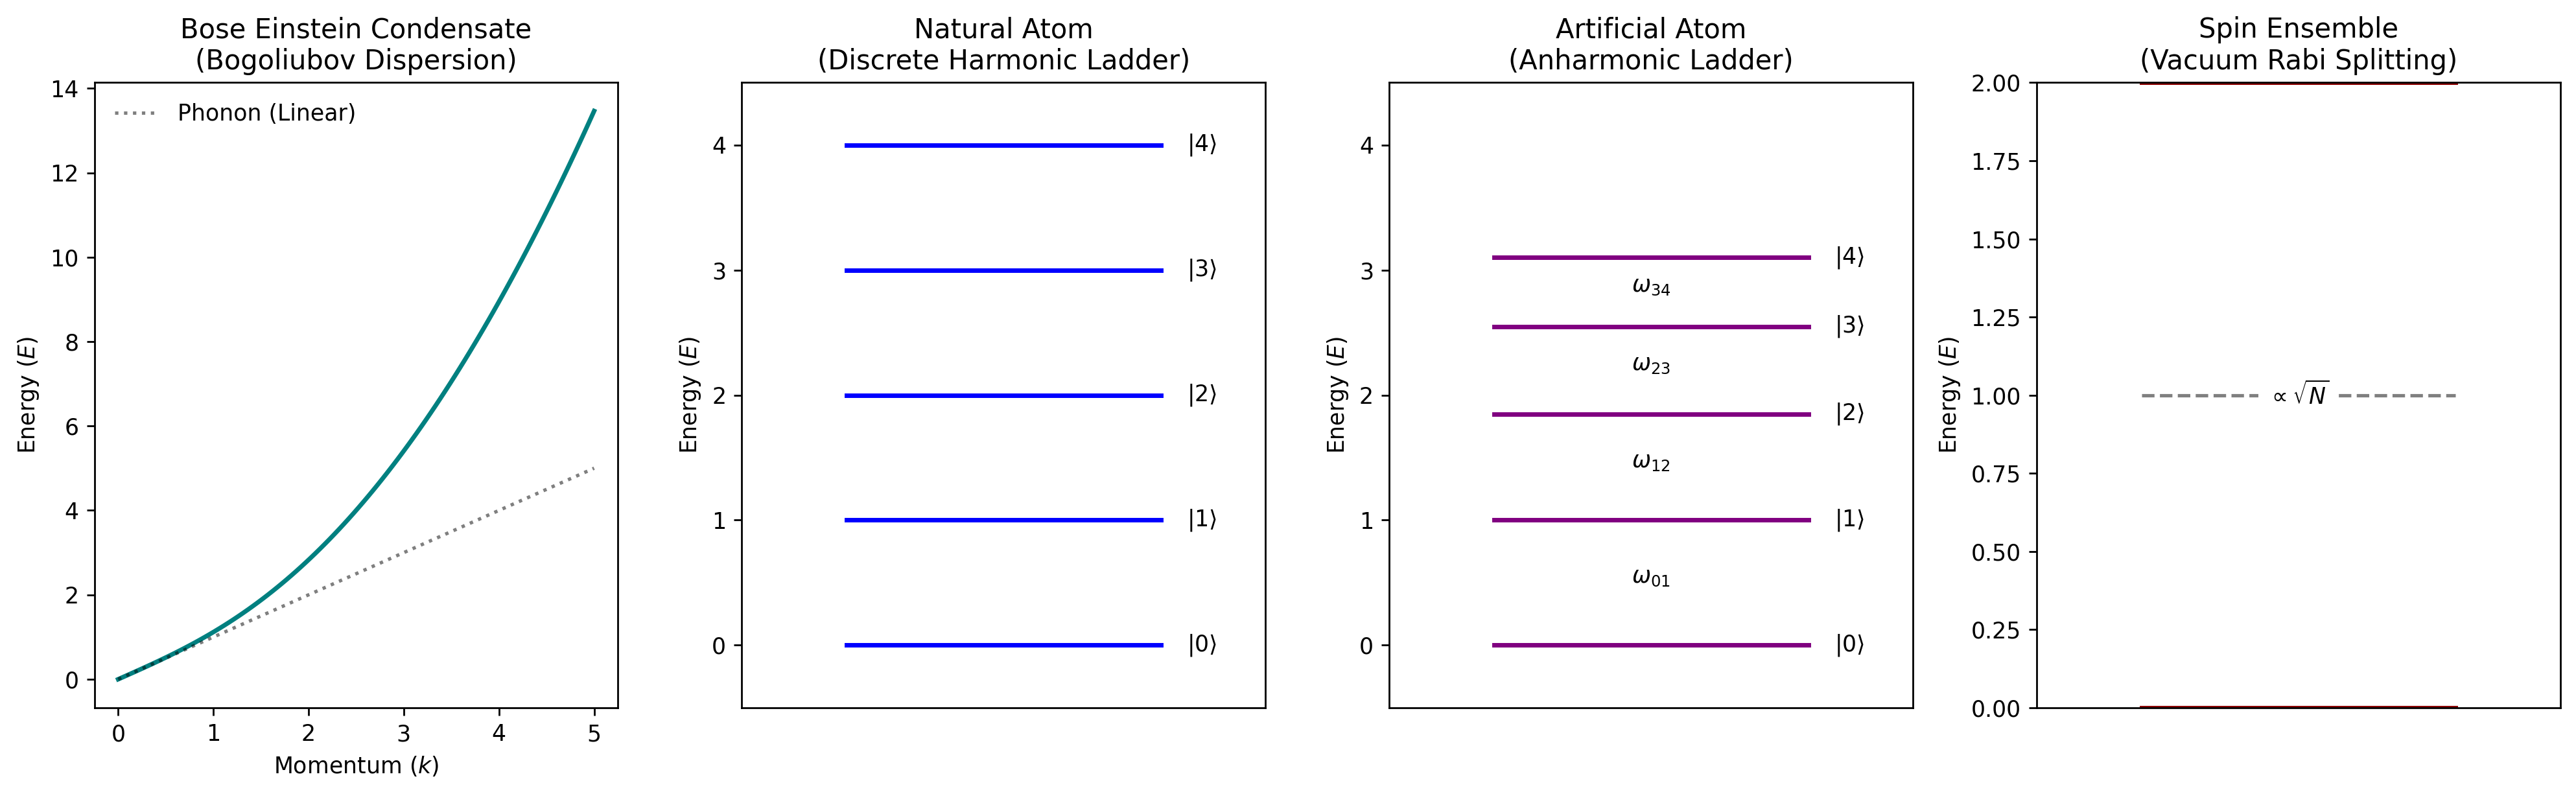

In [1]:
"""
Visualizing the characteristic energy spectra and dispersion relations of quantum hardware.

Scientific Purpose:
The script visually elucidates the transition from gapless continuous phonon spectra in
macroscopic condensates to the discrete, anharmonic transitions governing single-particle
qubits, and ultimately to the root-N scaled Dicke manifold of quantum ensembles.
"""

# Users can install necessary libraries via pip or uv:
# !uv pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Control Knobs (Parameter Adjustment)
# =============================================================================
WAVENUMBER_MAX = 5.0           # Maximum k-vector for BEC dispersion relation
SOUND_VELOCITY = 1.0           # Speed of sound in the condensate medium
HARMONIC_SPACING = 1.0         # Normalized energy spacing for natural atoms
ANHARMONICITY_FACTOR = 0.15    # Relative strength of qubit anharmonicity (Transmon)
ENSEMBLE_PARTICLES_N = 100     # Total number of atoms (N) in the dense ensemble
BASE_COUPLING_G = 0.1          # Base single-photon coupling rate
# =============================================================================

# Matplotlib styling for formal Nature-style rendering
plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def compute_bec_dispersion(k_array, c_s):
    """Compute the Bogoliubov dispersion relation for a BEC."""
    return np.sqrt((c_s * k_array)**2 + (0.5 * k_array**2)**2)

def compute_transmon_levels(levels, omega, alpha):
    """Compute the energy levels of a weakly anharmonic transmon."""
    return omega * levels - 0.5 * alpha * (levels**2 - levels)

def compute_ensemble_splitting(g, n_particles):
    """Compute the collective vacuum Rabi splitting for an ensemble."""
    return g * np.sqrt(n_particles)

def generate_visualizations():
    """Generate and display the comparative subplots for all four architectures."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    # 1. Bose Einstein Condensate (Continuous Dispersion)
    k_vals = np.linspace(0, WAVENUMBER_MAX, 100)
    e_bec = compute_bec_dispersion(k_vals, SOUND_VELOCITY)
    axes[0].plot(k_vals, e_bec, color='teal', linewidth=2)
    axes[0].plot(k_vals, SOUND_VELOCITY * k_vals, 'k:', alpha=0.5, label='Phonon (Linear)')
    axes[0].set_title("Bose Einstein Condensate\n(Bogoliubov Dispersion)")
    axes[0].set_xlabel("Momentum ($k$)")
    axes[0].set_ylabel("Energy ($E$)")
    axes[0].legend(loc='upper left', frameon=False)

    # 2. Natural Atom (Perfect Discrete Levels)
    n_levels = np.arange(5)
    e_natural = HARMONIC_SPACING * n_levels
    for i, e in enumerate(e_natural):
        axes[1].axhline(y=e, xmin=0.2, xmax=0.8, color='blue', linewidth=2)
        axes[1].text(0.85, e, f"$|{i}\\rangle$", va='center')
    axes[1].set_title("Natural Atom\n(Discrete Harmonic Ladder)")
    axes[1].set_xticks([])
    axes[1].set_ylabel("Energy ($E$)")
    axes[1].set_ylim(-0.5, 4.5)

    # 3. Artificial Atom / Transmon (Anharmonic Levels)
    e_transmon = compute_transmon_levels(n_levels, HARMONIC_SPACING, ANHARMONICITY_FACTOR)
    for i, e in enumerate(e_transmon):
        axes[2].axhline(y=e, xmin=0.2, xmax=0.8, color='purple', linewidth=2)
        axes[2].text(0.85, e, f"$|{i}\\rangle$", va='center')
        if i > 0:
            diff = e_transmon[i] - e_transmon[i-1]
            axes[2].annotate(f"$\\omega_{{{i-1}{i}}}$", xy=(0.5, e_transmon[i-1] + diff/2), ha='center')
    axes[2].set_title("Artificial Atom\n(Anharmonic Ladder)")
    axes[2].set_xticks([])
    axes[2].set_ylabel("Energy ($E$)")
    axes[2].set_ylim(-0.5, 4.5)

    # 4. Spin Ensemble (Root-N Splitting)
    split = compute_ensemble_splitting(BASE_COUPLING_G, ENSEMBLE_PARTICLES_N)
    axes[3].axhline(y=1, xmin=0.2, xmax=0.8, color='gray', linestyle='--', label='Uncoupled')
    axes[3].axhline(y=1 + split, xmin=0.2, xmax=0.8, color='darkred', linewidth=2)
    axes[3].axhline(y=1 - split, xmin=0.2, xmax=0.8, color='darkred', linewidth=2)
    axes[3].annotate(f"$\\propto \\sqrt{{N}}$", xy=(0.5, 1), ha='center', va='center',
                     bbox=dict(facecolor='white', edgecolor='none'))
    axes[3].set_title("Spin Ensemble\n(Vacuum Rabi Splitting)")
    axes[3].set_xticks([])
    axes[3].set_ylabel("Energy ($E$)")
    axes[3].set_ylim(0, 2)

    plt.tight_layout()
    plt.show() # Renders directly in Colab without saving to disk

if __name__ == "__main__":
    generate_visualizations()

Numerical diagnostics
---------------------
BEC sound speed: 1.8881e-03 m/s
BEC interaction scale g n / h: 7.7648e+02 Hz
BEC healing length: 2.7366e-01 micrometers
BEC healing wavenumber: 3.6542e+00 micrometers^-1
Natural atom Rabi frequency: 1.0000e+00 MHz
Transmon E_J / E_C: 8.0000e+01
Transmon f01: 6.0635e+00 GHz
Transmon f12: 5.7861e+00 GHz
Transmon f23: 5.4845e+00 GHz
Transmon anharmonicity f12 - f01: -2.7739e-01 GHz
Ensemble single-particle coupling g: 1.0000e-01 MHz
Ensemble collective coupling g sqrt(N): 1.0000e+00 MHz
Ensemble resonant splitting 2 g sqrt(N): 2.0000e+00 MHz


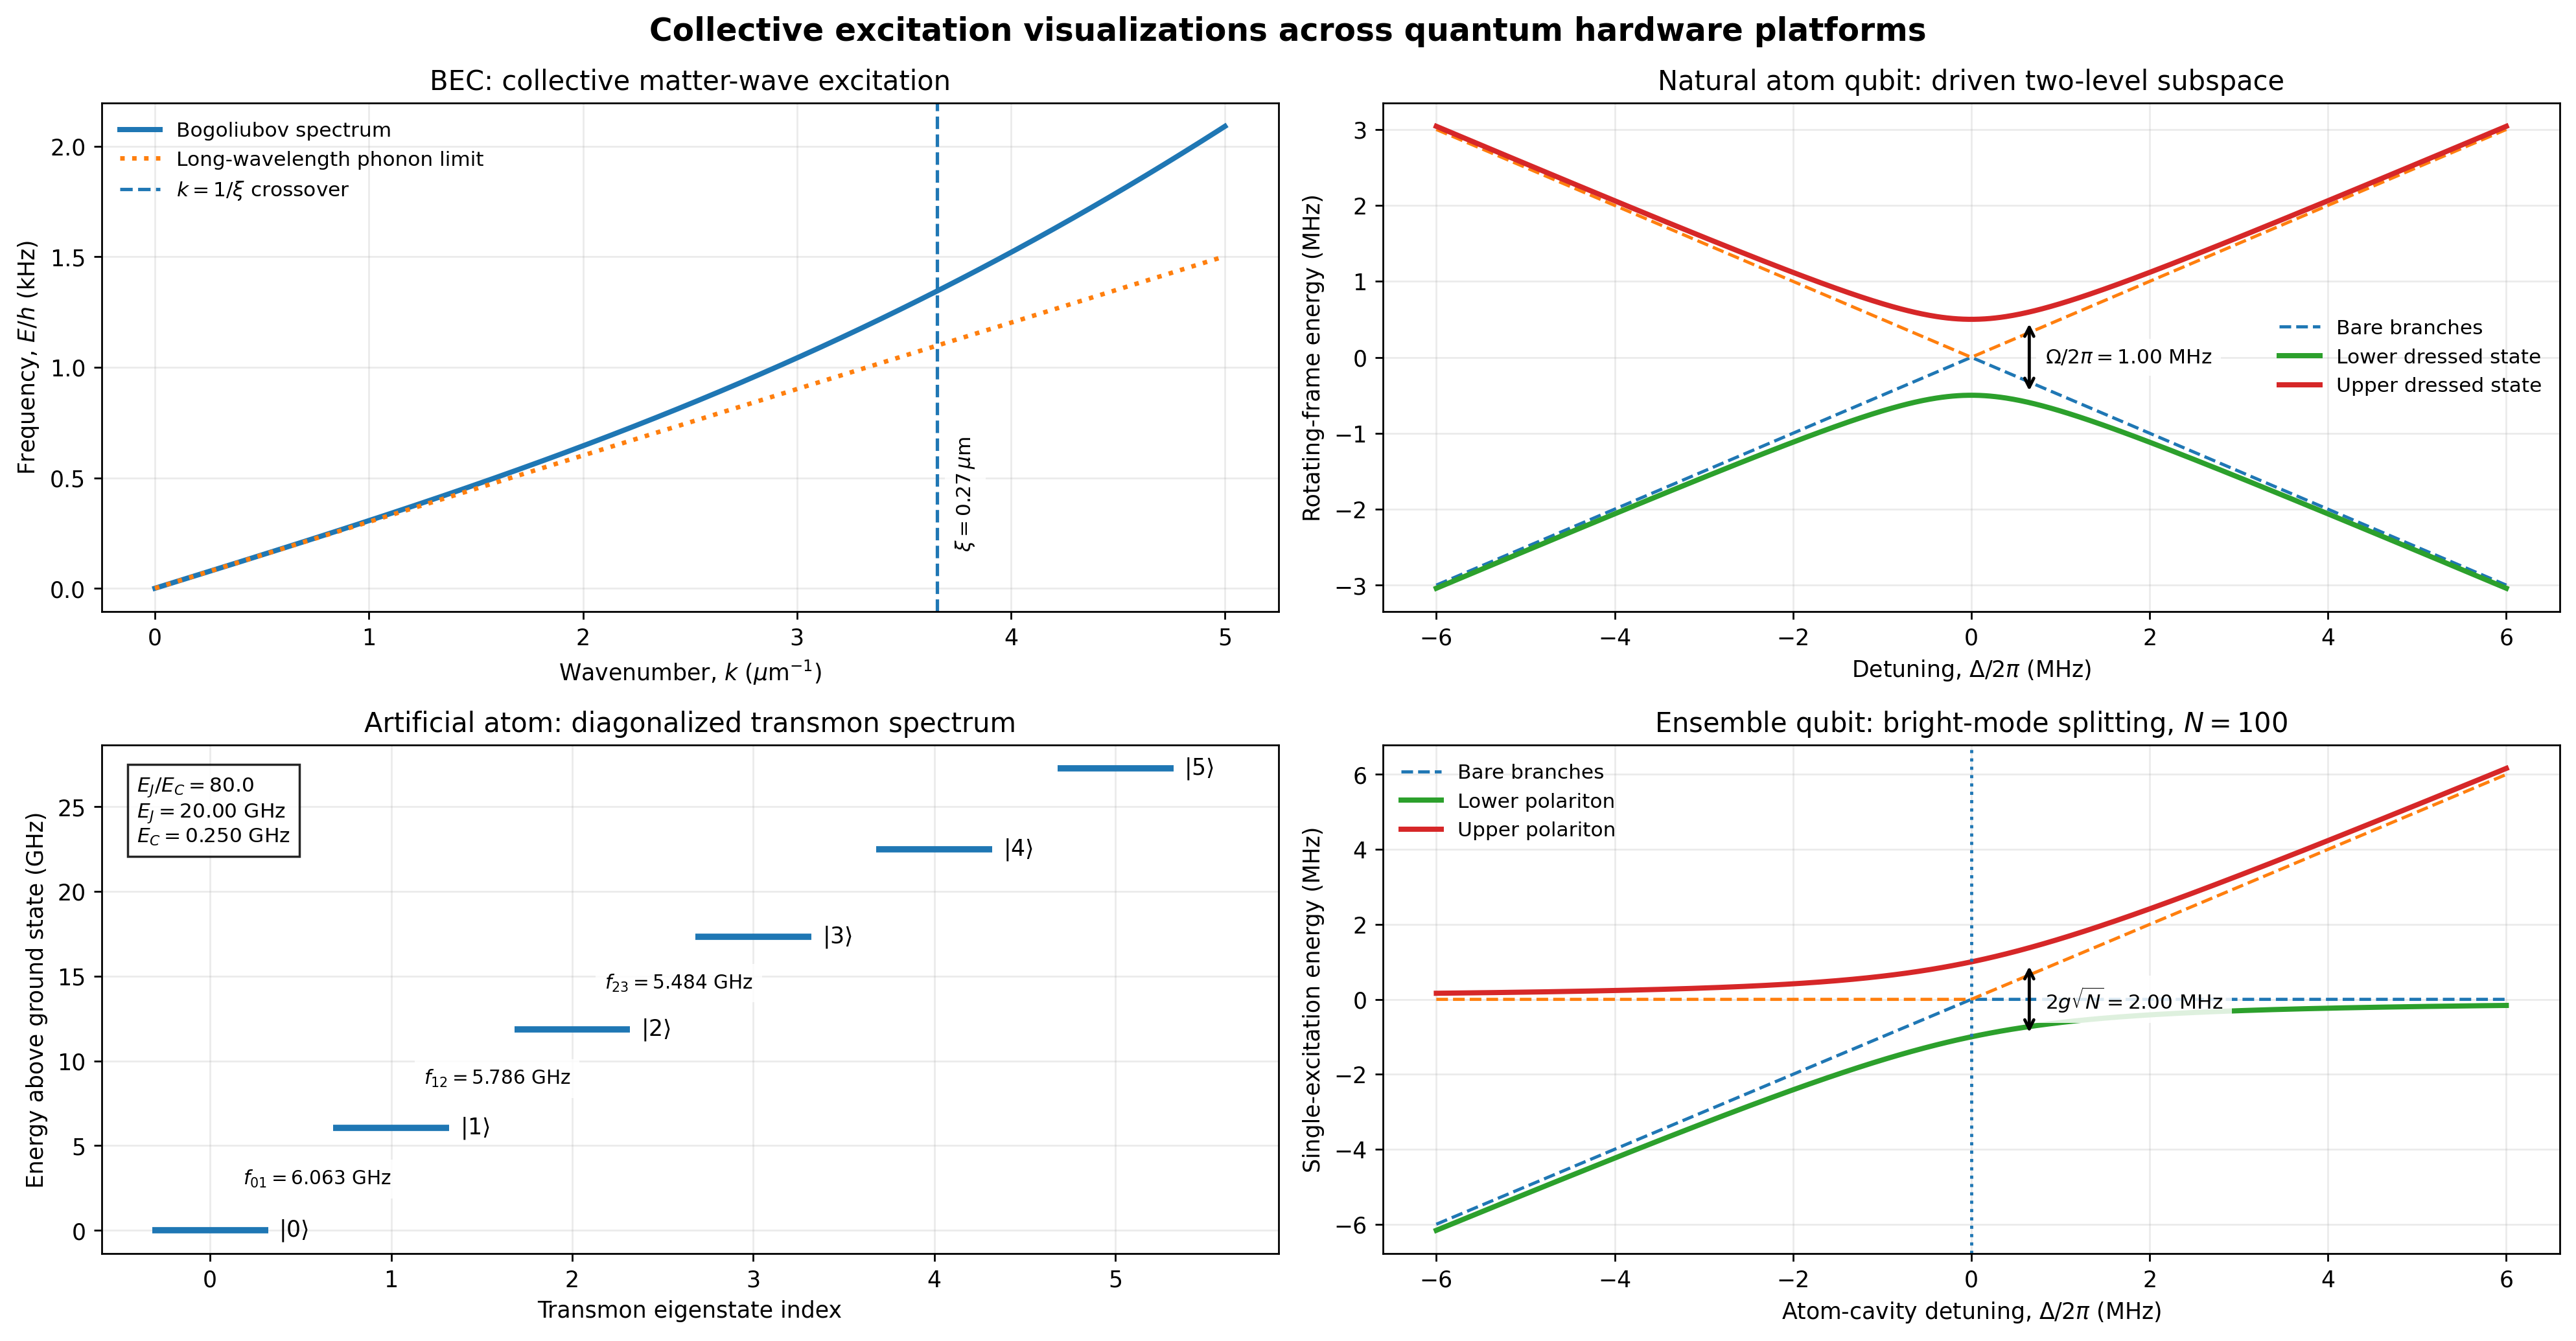

In [5]:
!uv pip install -q numpy scipy matplotlib qutip

"""
Compare collective excitation visualizations across BECs, natural atom qubits,
artificial atom qubits, and ensemble qubits.

The BEC panel uses a Bogoliubov dispersion computed from physical constants.
The natural atom panel uses a driven two-level Hamiltonian in the rotating frame.
The artificial atom panel diagonalizes a transmon Hamiltonian in the charge basis.
The ensemble panel diagonalizes a single-excitation bright-mode Hamiltonian with
collective sqrt(N) coupling.
"""

from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from scipy import constants as const
from scipy.linalg import eigh


# =============================================================================
# CONTROL KNOBS
# =============================================================================

MPL_DPI = 250
FIGURE_SIZE = (16.0, 8.4)

# BEC controls, approximately Rb-87-like.
BEC_ATOM_MASS_KG = 1.44316060e-25
BEC_SCATTERING_LENGTH_M = 5.313e-9
BEC_DENSITY_M3 = 1.0e20
BEC_K_MAX_UM_INV = 5.0
BEC_K_POINTS = 700

# Natural atom qubit controls, rotating-frame MHz units.
NATURAL_RABI_MHZ = 1.0
NATURAL_DETUNING_MIN_MHZ = -6.0
NATURAL_DETUNING_MAX_MHZ = 6.0
NATURAL_DETUNING_POINTS = 600

# Transmon controls, GHz units.
TRANSMON_EJ_GHZ = 20.0
TRANSMON_EC_GHZ = 0.250
TRANSMON_NG = 0.0
TRANSMON_CHARGE_CUTOFF = 35
TRANSMON_LEVELS_TO_PLOT = 6

# Ensemble controls, MHz units.
ENSEMBLE_PARTICLES_N = 100
ENSEMBLE_SINGLE_PARTICLE_G_MHZ = 0.10
ENSEMBLE_DETUNING_MIN_MHZ = -6.0
ENSEMBLE_DETUNING_MAX_MHZ = 6.0
ENSEMBLE_DETUNING_POINTS = 600


# =============================================================================
# DATA CONTAINERS
# =============================================================================

@dataclass(frozen=True)
class BecSpectrum:
    """Store a weakly interacting BEC Bogoliubov spectrum."""

    k_um_inv: np.ndarray
    frequency_hz: np.ndarray
    phonon_frequency_hz: np.ndarray
    sound_speed_m_per_s: float
    interaction_energy_hz: float
    healing_length_um: float
    healing_wavenumber_um_inv: float


@dataclass(frozen=True)
class DressedSpectrum:
    """Store a two-branch dressed-state spectrum."""

    detuning_mhz: np.ndarray
    lower_mhz: np.ndarray
    upper_mhz: np.ndarray
    bare_lower_mhz: np.ndarray
    bare_upper_mhz: np.ndarray


@dataclass(frozen=True)
class TransmonSpectrum:
    """Store transmon eigenenergies and transition frequencies."""

    levels_ghz: np.ndarray
    transitions_ghz: np.ndarray
    ej_over_ec: float


# =============================================================================
# COMPUTATION
# =============================================================================

def configure_matplotlib() -> None:
    """Configure Matplotlib for high-resolution Colab rendering."""
    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
    mpl.rcParams["font.weight"] = "normal"
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["grid.alpha"] = 0.25
    mpl.rcParams["axes.titleweight"] = "normal"


def compute_bec_bogoliubov_spectrum() -> BecSpectrum:
    """Compute a BEC Bogoliubov dispersion with physical units."""
    k_um_inv = np.linspace(0.0, BEC_K_MAX_UM_INV, BEC_K_POINTS)
    k_m_inv = k_um_inv * 1.0e6

    coupling_j_m3 = (
        4.0
        * np.pi
        * const.hbar**2
        * BEC_SCATTERING_LENGTH_M
        / BEC_ATOM_MASS_KG
    )
    interaction_energy_j = coupling_j_m3 * BEC_DENSITY_M3
    kinetic_energy_j = const.hbar**2 * k_m_inv**2 / (2.0 * BEC_ATOM_MASS_KG)

    bogoliubov_energy_j = np.sqrt(
        kinetic_energy_j * (kinetic_energy_j + 2.0 * interaction_energy_j)
    )
    sound_speed_m_per_s = np.sqrt(interaction_energy_j / BEC_ATOM_MASS_KG)
    phonon_energy_j = const.hbar * sound_speed_m_per_s * k_m_inv

    healing_length_m = const.hbar / np.sqrt(
        2.0 * BEC_ATOM_MASS_KG * interaction_energy_j
    )
    healing_length_um = healing_length_m * 1.0e6
    healing_wavenumber_um_inv = 1.0 / healing_length_um

    return BecSpectrum(
        k_um_inv=k_um_inv,
        frequency_hz=bogoliubov_energy_j / const.h,
        phonon_frequency_hz=phonon_energy_j / const.h,
        sound_speed_m_per_s=sound_speed_m_per_s,
        interaction_energy_hz=interaction_energy_j / const.h,
        healing_length_um=healing_length_um,
        healing_wavenumber_um_inv=healing_wavenumber_um_inv,
    )


def compute_natural_atom_dressed_spectrum() -> DressedSpectrum:
    """Compute driven two-level dressed states for a natural atom qubit."""
    detuning_mhz = np.linspace(
        NATURAL_DETUNING_MIN_MHZ,
        NATURAL_DETUNING_MAX_MHZ,
        NATURAL_DETUNING_POINTS,
    )

    lower_mhz = np.empty_like(detuning_mhz)
    upper_mhz = np.empty_like(detuning_mhz)

    sigma_x = qt.sigmax()
    sigma_z = qt.sigmaz()

    for index, detuning in enumerate(detuning_mhz):
        hamiltonian = (
            0.5 * detuning * sigma_z
            + 0.5 * NATURAL_RABI_MHZ * sigma_x
        )
        eigenenergies = np.sort(np.real(hamiltonian.eigenenergies()))
        lower_mhz[index] = eigenenergies[0]
        upper_mhz[index] = eigenenergies[1]

    bare_lower_mhz = -0.5 * np.abs(detuning_mhz)
    bare_upper_mhz = 0.5 * np.abs(detuning_mhz)

    return DressedSpectrum(
        detuning_mhz=detuning_mhz,
        lower_mhz=lower_mhz,
        upper_mhz=upper_mhz,
        bare_lower_mhz=bare_lower_mhz,
        bare_upper_mhz=bare_upper_mhz,
    )


def build_transmon_charge_hamiltonian() -> np.ndarray:
    """Build the transmon Hamiltonian in the Cooper-pair number basis."""
    charge_numbers = np.arange(
        -TRANSMON_CHARGE_CUTOFF,
        TRANSMON_CHARGE_CUTOFF + 1,
        dtype=float,
    )
    dimension = charge_numbers.size

    hamiltonian = np.diag(
        4.0 * TRANSMON_EC_GHZ * (charge_numbers - TRANSMON_NG) ** 2
    )

    for row in range(dimension - 1):
        hamiltonian[row, row + 1] = -0.5 * TRANSMON_EJ_GHZ
        hamiltonian[row + 1, row] = -0.5 * TRANSMON_EJ_GHZ

    return hamiltonian


def compute_transmon_spectrum() -> TransmonSpectrum:
    """Diagonalize the transmon Hamiltonian and compute transitions."""
    hamiltonian = build_transmon_charge_hamiltonian()
    eigenvalues_ghz = eigh(hamiltonian, eigvals_only=True)

    levels_ghz = eigenvalues_ghz[:TRANSMON_LEVELS_TO_PLOT]
    levels_ghz = levels_ghz - levels_ghz[0]
    transitions_ghz = np.diff(levels_ghz)

    return TransmonSpectrum(
        levels_ghz=levels_ghz,
        transitions_ghz=transitions_ghz,
        ej_over_ec=TRANSMON_EJ_GHZ / TRANSMON_EC_GHZ,
    )


def compute_ensemble_bright_mode_spectrum() -> DressedSpectrum:
    """Compute a bright-mode ensemble avoided crossing."""
    detuning_mhz = np.linspace(
        ENSEMBLE_DETUNING_MIN_MHZ,
        ENSEMBLE_DETUNING_MAX_MHZ,
        ENSEMBLE_DETUNING_POINTS,
    )

    collective_g_mhz = (
        ENSEMBLE_SINGLE_PARTICLE_G_MHZ * np.sqrt(ENSEMBLE_PARTICLES_N)
    )

    lower_mhz = np.empty_like(detuning_mhz)
    upper_mhz = np.empty_like(detuning_mhz)

    for index, detuning in enumerate(detuning_mhz):
        hamiltonian = qt.Qobj(
            np.array(
                [
                    [0.0, collective_g_mhz],
                    [collective_g_mhz, detuning],
                ],
                dtype=float,
            )
        )
        eigenenergies = np.sort(np.real(hamiltonian.eigenenergies()))
        lower_mhz[index] = eigenenergies[0]
        upper_mhz[index] = eigenenergies[1]

    bare_lower_mhz = np.minimum(0.0, detuning_mhz)
    bare_upper_mhz = np.maximum(0.0, detuning_mhz)

    return DressedSpectrum(
        detuning_mhz=detuning_mhz,
        lower_mhz=lower_mhz,
        upper_mhz=upper_mhz,
        bare_lower_mhz=bare_lower_mhz,
        bare_upper_mhz=bare_upper_mhz,
    )


# =============================================================================
# PLOTTING
# =============================================================================

def annotate_vertical_splitting(
    axis: plt.Axes,
    x_value: float,
    y_min: float,
    y_max: float,
    label: str,
) -> None:
    """Annotate an energy splitting using a double-headed arrow."""
    axis.annotate(
        "",
        xy=(x_value, y_max),
        xytext=(x_value, y_min),
        arrowprops={"arrowstyle": "<->", "linewidth": 1.4},
    )
    axis.text(
        x_value + 0.18,
        0.5 * (y_min + y_max),
        label,
        va="center",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
    )


def plot_energy_comparison(
    bec: BecSpectrum,
    natural_atom: DressedSpectrum,
    transmon: TransmonSpectrum,
    ensemble: DressedSpectrum,
) -> None:
    """Render the four-platform excitation comparison."""
    fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE)
    axes = axes.ravel()

    axes[0].plot(
        bec.k_um_inv,
        bec.frequency_hz / 1.0e3,
        linewidth=2.3,
        label="Bogoliubov spectrum",
    )
    axes[0].plot(
        bec.k_um_inv,
        bec.phonon_frequency_hz / 1.0e3,
        linestyle=":",
        linewidth=2.0,
        label="Long-wavelength phonon limit",
    )
    if bec.healing_wavenumber_um_inv <= BEC_K_MAX_UM_INV:
        axes[0].axvline(
            bec.healing_wavenumber_um_inv,
            linestyle="--",
            linewidth=1.5,
            label=r"$k=1/\xi$ crossover",
        )
        axes[0].text(
            bec.healing_wavenumber_um_inv + 0.08,
            0.08 * np.max(bec.frequency_hz / 1.0e3),
            rf"$\xi={bec.healing_length_um:.2f}\,\mu$m",
            rotation=90,
            va="bottom",
            fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
        )
    axes[0].set_title("BEC: collective matter-wave excitation")
    axes[0].set_xlabel(r"Wavenumber, $k$ ($\mu$m$^{-1}$)")
    axes[0].set_ylabel(r"Frequency, $E/h$ (kHz)")
    axes[0].legend(frameon=False, fontsize=9)

    axes[1].plot(
        natural_atom.detuning_mhz,
        natural_atom.bare_lower_mhz,
        linestyle="--",
        linewidth=1.4,
        label="Bare branches",
    )
    axes[1].plot(
        natural_atom.detuning_mhz,
        natural_atom.bare_upper_mhz,
        linestyle="--",
        linewidth=1.4,
    )
    axes[1].plot(
        natural_atom.detuning_mhz,
        natural_atom.lower_mhz,
        linewidth=2.3,
        label="Lower dressed state",
    )
    axes[1].plot(
        natural_atom.detuning_mhz,
        natural_atom.upper_mhz,
        linewidth=2.3,
        label="Upper dressed state",
    )
    annotate_vertical_splitting(
        axis=axes[1],
        x_value=0.65,
        y_min=-0.5 * NATURAL_RABI_MHZ,
        y_max=0.5 * NATURAL_RABI_MHZ,
        label=rf"$\Omega/2\pi={NATURAL_RABI_MHZ:.2f}$ MHz",
    )
    axes[1].set_title("Natural atom qubit: driven two-level subspace")
    axes[1].set_xlabel(r"Detuning, $\Delta/2\pi$ (MHz)")
    axes[1].set_ylabel("Rotating-frame energy (MHz)")
    axes[1].legend(frameon=False, fontsize=9)

    level_index = np.arange(transmon.levels_ghz.size)
    for index, energy in zip(level_index, transmon.levels_ghz):
        axes[2].hlines(
            energy,
            index - 0.32,
            index + 0.32,
            linewidth=2.8,
        )
        axes[2].text(
            index + 0.38,
            energy,
            rf"$|{index}\rangle$",
            va="center",
        )

    for index, transition in enumerate(transmon.transitions_ghz[:3]):
        y_mid = 0.5 * (
            transmon.levels_ghz[index]
            + transmon.levels_ghz[index + 1]
        )
        axes[2].annotate(
            rf"$f_{{{index}{index + 1}}}={transition:.3f}$ GHz",
            xy=(index + 0.18, y_mid),
            fontsize=8.5,
            ha="left",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
        )

    transmon_text = (
        rf"$E_J/E_C={transmon.ej_over_ec:.1f}$" "\n"
        rf"$E_J={TRANSMON_EJ_GHZ:.2f}$ GHz" "\n"
        rf"$E_C={TRANSMON_EC_GHZ:.3f}$ GHz"
    )
    axes[2].text(
        0.03,
        0.94,
        transmon_text,
        transform=axes[2].transAxes,
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.85},
    )
    axes[2].set_title("Artificial atom: diagonalized transmon spectrum")
    axes[2].set_xlabel("Transmon eigenstate index")
    axes[2].set_ylabel("Energy above ground state (GHz)")
    axes[2].set_xticks(level_index)
    axes[2].set_xlim(-0.6, transmon.levels_ghz.size - 0.1)

    axes[3].plot(
        ensemble.detuning_mhz,
        ensemble.bare_lower_mhz,
        linestyle="--",
        linewidth=1.4,
        label="Bare branches",
    )
    axes[3].plot(
        ensemble.detuning_mhz,
        ensemble.bare_upper_mhz,
        linestyle="--",
        linewidth=1.4,
    )
    axes[3].plot(
        ensemble.detuning_mhz,
        ensemble.lower_mhz,
        linewidth=2.3,
        label="Lower polariton",
    )
    axes[3].plot(
        ensemble.detuning_mhz,
        ensemble.upper_mhz,
        linewidth=2.3,
        label="Upper polariton",
    )

    collective_g_mhz = (
        ENSEMBLE_SINGLE_PARTICLE_G_MHZ * np.sqrt(ENSEMBLE_PARTICLES_N)
    )
    annotate_vertical_splitting(
        axis=axes[3],
        x_value=0.65,
        y_min=-collective_g_mhz,
        y_max=collective_g_mhz,
        label=rf"$2g\sqrt{{N}}={2.0 * collective_g_mhz:.2f}$ MHz",
    )
    axes[3].axvline(0.0, linestyle=":", linewidth=1.4)
    axes[3].set_title(
        rf"Ensemble qubit: bright-mode splitting, $N={ENSEMBLE_PARTICLES_N}$"
    )
    axes[3].set_xlabel(r"Atom-cavity detuning, $\Delta/2\pi$ (MHz)")
    axes[3].set_ylabel("Single-excitation energy (MHz)")
    axes[3].legend(frameon=False, fontsize=9)

    fig.suptitle(
        "Collective excitation visualizations across quantum hardware platforms",
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout()
    plt.show()


# =============================================================================
# REPORTING
# =============================================================================

def print_summary(
    bec: BecSpectrum,
    transmon: TransmonSpectrum,
) -> None:
    """Print compact numerical diagnostics for sanity checking."""
    collective_g_mhz = (
        ENSEMBLE_SINGLE_PARTICLE_G_MHZ * np.sqrt(ENSEMBLE_PARTICLES_N)
    )
    transmon_anharmonicity_ghz = (
        transmon.transitions_ghz[1] - transmon.transitions_ghz[0]
    )

    print("Numerical diagnostics")
    print("---------------------")
    print(f"BEC sound speed: {bec.sound_speed_m_per_s:.4e} m/s")
    print(f"BEC interaction scale g n / h: {bec.interaction_energy_hz:.4e} Hz")
    print(f"BEC healing length: {bec.healing_length_um:.4e} micrometers")
    print(
        "BEC healing wavenumber: "
        f"{bec.healing_wavenumber_um_inv:.4e} micrometers^-1"
    )
    print(f"Natural atom Rabi frequency: {NATURAL_RABI_MHZ:.4e} MHz")
    print(f"Transmon E_J / E_C: {transmon.ej_over_ec:.4e}")
    print(f"Transmon f01: {transmon.transitions_ghz[0]:.4e} GHz")
    print(f"Transmon f12: {transmon.transitions_ghz[1]:.4e} GHz")
    print(f"Transmon f23: {transmon.transitions_ghz[2]:.4e} GHz")
    print(
        "Transmon anharmonicity f12 - f01: "
        f"{transmon_anharmonicity_ghz:.4e} GHz"
    )
    print(f"Ensemble single-particle coupling g: {ENSEMBLE_SINGLE_PARTICLE_G_MHZ:.4e} MHz")
    print(f"Ensemble collective coupling g sqrt(N): {collective_g_mhz:.4e} MHz")
    print(f"Ensemble resonant splitting 2 g sqrt(N): {2.0 * collective_g_mhz:.4e} MHz")


def main() -> None:
    """Run the full comparison workflow."""
    configure_matplotlib()

    bec = compute_bec_bogoliubov_spectrum()
    natural_atom = compute_natural_atom_dressed_spectrum()
    transmon = compute_transmon_spectrum()
    ensemble = compute_ensemble_bright_mode_spectrum()

    print_summary(bec=bec, transmon=transmon)
    plot_energy_comparison(
        bec=bec,
        natural_atom=natural_atom,
        transmon=transmon,
        ensemble=ensemble,
    )

if __name__ == "__main__":
    main()